## Define project folder, output folders, and CAMELS attribute folder

In this step, I define the main project folder, create output folders, and set the folder that contains the CAMELS attribute text files.

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [2]:

# 1) Main project folder
PROJECT_DIR = Path(
    r"C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis"
)

# 2) Output folders
OUT_DIR = PROJECT_DIR / "outputs"
OUT_SUMMARY = OUT_DIR / "summary_csv"
OUT_PDF = OUT_DIR / "pdf"
OUT_LOGS = OUT_DIR / "logs"

# Create folders
OUT_SUMMARY.mkdir(parents=True, exist_ok=True)
OUT_PDF.mkdir(parents=True, exist_ok=True)
OUT_LOGS.mkdir(parents=True, exist_ok=True)

# 3) CAMELS attribute folder
ATTR_DIR = Path(
    r"C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research"
)

# 4) Check paths
print("PROJECT_DIR:")
print(PROJECT_DIR)

print("\nOutput folders:")
print(OUT_SUMMARY)
print(OUT_PDF)
print(OUT_LOGS)

print("\nATTR_DIR:")
print(ATTR_DIR)

print("\nDoes ATTR_DIR exist? ->", ATTR_DIR.exists())
print("Does camels_clim.txt exist? ->", (ATTR_DIR / "camels_clim.txt").exists())
print("Does camels_soil.txt exist? ->", (ATTR_DIR / "camels_soil.txt").exists())
print("Does camels_topo.txt exist? ->", (ATTR_DIR / "camels_topo.txt").exists())
print("Does camels_hydro.txt exist? ->", (ATTR_DIR / "camels_hydro.txt").exists())
print("Does camels_geol.txt exist? ->", (ATTR_DIR / "camels_geol.txt").exists())
print("Does camels_vege.txt exist? ->", (ATTR_DIR / "camels_vege.txt").exists())
print("Does camels_name.txt exist? ->", (ATTR_DIR / "camels_name.txt").exists())

PROJECT_DIR:
C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis

Output folders:
C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis\outputs\summary_csv
C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis\outputs\pdf
C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis\outputs\logs

ATTR_DIR:
C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research

Does ATTR_DIR exist? -> True
Does camels_clim.txt exist? -> True
Does camels_soil.txt exist? -> True
Does camels_topo.txt exist? -> True
Does camels_hydro.txt exist? -> True
D

## Read CAMELS attribute files and inspect columns

In this step, I read all CAMELS attribute text files and check their size and column names.
This will help me choose the hydrologic factors for basin-to-basin TE analysis.

In [3]:
clim_df  = pd.read_csv(ATTR_DIR / "camels_clim.txt", sep=";")
geol_df  = pd.read_csv(ATTR_DIR / "camels_geol.txt", sep=";")
hydro_df = pd.read_csv(ATTR_DIR / "camels_hydro.txt", sep=";")
soil_df  = pd.read_csv(ATTR_DIR / "camels_soil.txt", sep=";")
topo_df  = pd.read_csv(ATTR_DIR / "camels_topo.txt", sep=";")
vege_df  = pd.read_csv(ATTR_DIR / "camels_vege.txt", sep=";")
name_df  = pd.read_csv(ATTR_DIR / "camels_name.txt", sep=";")

# Check shape
print("clim_df :", clim_df.shape)
print("geol_df :", geol_df.shape)
print("hydro_df:", hydro_df.shape)
print("soil_df :", soil_df.shape)
print("topo_df :", topo_df.shape)
print("vege_df :", vege_df.shape)
print("name_df :", name_df.shape)

# Show column names
print("\nClimate columns:")
print(clim_df.columns.tolist())

print("\nGeology columns:")
print(geol_df.columns.tolist())

print("\nHydrology columns:")
print(hydro_df.columns.tolist())

print("\nSoil columns:")
print(soil_df.columns.tolist())

print("\nTopography columns:")
print(topo_df.columns.tolist())

print("\nVegetation columns:")
print(vege_df.columns.tolist())

print("\nName columns:")
print(name_df.columns.tolist())

clim_df : (671, 12)
geol_df : (671, 8)
hydro_df: (671, 14)
soil_df : (671, 12)
topo_df : (671, 7)
vege_df : (671, 10)
name_df : (671, 3)

Climate columns:
['gauge_id', 'p_mean', 'pet_mean', 'p_seasonality', 'frac_snow', 'aridity', 'high_prec_freq', 'high_prec_dur', 'high_prec_timing', 'low_prec_freq', 'low_prec_dur', 'low_prec_timing']

Geology columns:
['gauge_id', 'geol_1st_class', 'glim_1st_class_frac', 'geol_2nd_class', 'glim_2nd_class_frac', 'carbonate_rocks_frac', 'geol_porostiy', 'geol_permeability']

Hydrology columns:
['gauge_id', 'q_mean', 'runoff_ratio', 'slope_fdc', 'baseflow_index', 'stream_elas', 'q5', 'q95', 'high_q_freq', 'high_q_dur', 'low_q_freq', 'low_q_dur', 'zero_q_freq', 'hfd_mean']

Soil columns:
['gauge_id', 'soil_depth_pelletier', 'soil_depth_statsgo', 'soil_porosity', 'soil_conductivity', 'max_water_content', 'sand_frac', 'silt_frac', 'clay_frac', 'water_frac', 'organic_frac', 'other_frac']

Topography columns:
['gauge_id', 'gauge_lat', 'gauge_lon', 'elev_mean

## Merge all CAMELS attribute tables into one dataframe

In this step, I merge all CAMELS attribute tables by `gauge_id` to create one combined basin-attribute dataframe.

In [4]:
# Start from basin names
camels_attr_df = name_df.copy()

# Merge all attribute tables by gauge_id
camels_attr_df = camels_attr_df.merge(clim_df, on="gauge_id", how="left")
camels_attr_df = camels_attr_df.merge(geol_df, on="gauge_id", how="left")
camels_attr_df = camels_attr_df.merge(hydro_df, on="gauge_id", how="left")
camels_attr_df = camels_attr_df.merge(soil_df, on="gauge_id", how="left")
camels_attr_df = camels_attr_df.merge(topo_df, on="gauge_id", how="left")
camels_attr_df = camels_attr_df.merge(vege_df, on="gauge_id", how="left")

# Check result
print("Combined CAMELS attribute dataframe shape:")
print(camels_attr_df.shape)

print("\nFirst 5 rows:")
display(camels_attr_df.head())

print("\nNumber of unique basins:")
print(camels_attr_df["gauge_id"].nunique())

Combined CAMELS attribute dataframe shape:
(671, 60)

First 5 rows:


,gauge_id,huc_02,gauge_name,p_mean,pet_mean,p_seasonality,frac_snow,aridity,high_prec_freq,high_prec_dur,...,area_geospa_fabric,frac_forest,lai_max,lai_diff,gvf_max,gvf_diff,dom_land_cover_frac,dom_land_cover,root_depth_50,root_depth_99
0,1013500,1,"Fish River near Fort Kent, Maine",3.126679,1.971555,0.187940,0.313440,0.630559,12.95,1.348958,...,2303.95,0.9063,4.167304,3.340732,0.804567,0.371648,0.883452,Mixed Forests,NaN,NaN
1,1022500,1,"Narraguagus River at Cherryfield, Maine",3.608126,2.119256,-0.114530,0.245259,0.587356,20.55,1.205279,...,620.38,0.9232,4.871392,3.746692,0.863936,0.337712,0.820493,Mixed Forests,0.237435,2.238444
2,1030500,1,"Mattawamkeag River near Mattawamkeag, Maine",3.274405,2.043594,0.047358,0.277018,0.624111,17.15,1.207746,...,3676.09,0.8782,4.685200,3.665543,0.858502,0.351393,0.975258,Mixed Forests,NaN,NaN
3,1031500,1,"Piscataquis River near Dover-Foxcroft, Maine",3.522957,2.071324,0.104091,0.291836,0.587950,18.90,1.148936,...,766.53,0.9548,4.903259,3.990843,0.870668,0.398619,1.000000,Mixed Forests,0.250000,2.400000
4,1047000,1,"Carrabassett River near North Anson, Maine",3.323146,2.090024,0.147776,0.280118,0.628929,20.10,1.165217,...,904.94,0.9906,5.086811,4.300978,0.891383,0.445473,0.850450,Mixed Forests,0.241027,2.340180



Number of unique basins:
671


## Save combined CAMELS attribute table

In this step, I save the combined CAMELS basin-attribute dataframe as a CSV file for later TE analysis.

In [5]:
# Save combined CAMELS attribute table
camels_attr_csv = OUT_SUMMARY / "camels_attributes_combined_671basins.csv"
camels_attr_df.to_csv(camels_attr_csv, index=False)

print("Saved:")
print(camels_attr_csv)

Saved:
C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis\outputs\summary_csv\camels_attributes_combined_671basins.csv


## Locate existing TE summary CSV files

In this step, I define the folder where my previous TE results are stored and list all CSV files inside it.
This will help me choose the correct TE summary file for basin-to-basin analysis.

In [6]:
# Folder where your previous TE summary CSV files are stored
TE_SUMMARY_DIR = Path(
    r"C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\summary_csv"
)

print("TE_SUMMARY_DIR:")
print(TE_SUMMARY_DIR)

print("\nDoes folder exist? ->", TE_SUMMARY_DIR.exists())

# List all CSV files
te_csv_files = sorted(TE_SUMMARY_DIR.glob("*.csv"))

print("\nCSV files found:")
for f in te_csv_files:
    print(f.name)

print("\nTotal CSV files found:", len(te_csv_files))

TE_SUMMARY_DIR:
C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\summary_csv

Does folder exist? -> True

CSV files found:
AllBasins_DataDateRanges.csv
basin_to_basin_dominant_forcing.csv
dominant_forcing_per_basin.csv
dominant_te_per_basin.csv
Probability_Distributions_Summary.csv
Q_clean_continuity_check_all671.csv
Q_cleaning_summary_from_raw_all671.csv
Q_temporal_ranges_all671.csv
Q_temporal_ranges_all671_cleanQ.csv
Q_temporal_ranges_all671_rawfile.csv
TE_AllBasins_tau1_30_PRCPspecial_bins5.csv
TE_dominant_forcing_per_basin.csv
TimeSeries_DateRanges_All671.csv
TimeSeries_DateRanges_AllYEAR_All671.csv

Total CSV files found: 14


## Inspect key TE summary CSV files

In this step, I open the main TE-related CSV files and check their columns and first few rows.
This will help me choose the correct TE summary table for basin-to-basin analysis.

In [7]:
# TE-related candidate files to inspect
candidate_files = [
    "TE_AllBasins_tau1_30_PRCPspecial_bins5.csv",
    "TE_dominant_forcing_per_basin.csv",
    "dominant_te_per_basin.csv",
    "dominant_forcing_per_basin.csv",
    "basin_to_basin_dominant_forcing.csv",
]

for file_name in candidate_files:
    file_path = TE_SUMMARY_DIR / file_name
    
    print("=" * 90)
    print("FILE:", file_name)
    
    if not file_path.exists():
        print("Not found")
        continue
    
    df = pd.read_csv(file_path)
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("\nFirst 5 rows:")
    display(df.head())
    print()

FILE: TE_AllBasins_tau1_30_PRCPspecial_bins5.csv
Shape: (80520, 7)
Columns: ['gauge_id', 'huc_02', 'Source', 'Target', 'Bins', 'Lag', 'TE_nats']

First 5 rows:


,gauge_id,huc_02,Source,Target,Bins,Lag,TE_nats
0,1013500,1,PRCP,Q,5,1,0.002761
1,1013500,1,PRCP,Q,5,2,0.001754
2,1013500,1,PRCP,Q,5,3,0.001439
3,1013500,1,PRCP,Q,5,4,0.000913
4,1013500,1,PRCP,Q,5,5,0.001240



FILE: TE_dominant_forcing_per_basin.csv
Shape: (671, 4)
Columns: ['gauge_id', 'dominant_forcing', 'peak_lag', 'peak_TE']

First 5 rows:


,gauge_id,dominant_forcing,peak_lag,peak_TE
0,1013500,Tair,14,0.004888
1,1022500,PRCP,1,0.016681
2,1030500,PRCP,1,0.013428
3,1031500,PRCP,1,0.003859
4,1047000,PRCP,1,0.002277



FILE: dominant_te_per_basin.csv
Shape: (671, 5)
Columns: ['gauge_id', 'PRCP', 'SRAD', 'Tair', 'VP']

First 5 rows:


,gauge_id,PRCP,SRAD,Tair,VP
0,1013500,0.002761,0.003063,0.004888,0.002685
1,1022500,0.016681,0.004775,0.008300,0.006192
2,1030500,0.013428,0.004072,0.007460,0.005949
3,1031500,0.003859,0.001481,0.001351,0.001597
4,1047000,0.002277,0.001389,0.001541,0.001330



FILE: dominant_forcing_per_basin.csv
Shape: (671, 2)
Columns: ['gauge_id', 'dominant_forcing']

First 5 rows:


,gauge_id,dominant_forcing
0,1013500,Tair
1,1022500,PRCP
2,1030500,PRCP
3,1031500,PRCP
4,1047000,PRCP



FILE: basin_to_basin_dominant_forcing.csv
Shape: (671, 8)
Columns: ['gauge_id', 'dominant_forcing', 'peak_lag', 'peak_TE', 'PRCP', 'SRAD', 'Tair', 'VP']

First 5 rows:


,gauge_id,dominant_forcing,peak_lag,peak_TE,PRCP,SRAD,Tair,VP
0,1013500,Tair,14,0.004888,0.002761,0.003063,0.004888,0.002685
1,1022500,PRCP,1,0.016681,0.016681,0.004775,0.008300,0.006192
2,1030500,PRCP,1,0.013428,0.013428,0.004072,0.007460,0.005949
3,1031500,PRCP,1,0.003859,0.003859,0.001481,0.001351,0.001597
4,1047000,PRCP,1,0.002277,0.002277,0.001389,0.001541,0.001330


## Load the main TE summary table

In this step, I load the main TE summary table for all 671 basins.
This table will be used to join TE results with CAMELS basin attributes.

In [8]:
# Main TE summary file to use
te_summary_file = TE_SUMMARY_DIR / "basin_to_basin_dominant_forcing.csv"

# Read TE summary table
te_summary_df = pd.read_csv(te_summary_file)

print("TE summary shape:")
print(te_summary_df.shape)

print("\nColumns:")
print(te_summary_df.columns.tolist())

print("\nFirst 5 rows:")
display(te_summary_df.head())

print("\nNumber of unique basins:")
print(te_summary_df["gauge_id"].nunique())

# Save a copy in the new project folder
te_summary_copy = OUT_SUMMARY / "te_summary_main_671basins.csv"
te_summary_df.to_csv(te_summary_copy, index=False)

print("\nSaved copy:")
print(te_summary_copy)

TE summary shape:
(671, 8)

Columns:
['gauge_id', 'dominant_forcing', 'peak_lag', 'peak_TE', 'PRCP', 'SRAD', 'Tair', 'VP']

First 5 rows:


,gauge_id,dominant_forcing,peak_lag,peak_TE,PRCP,SRAD,Tair,VP
0,1013500,Tair,14,0.004888,0.002761,0.003063,0.004888,0.002685
1,1022500,PRCP,1,0.016681,0.016681,0.004775,0.008300,0.006192
2,1030500,PRCP,1,0.013428,0.013428,0.004072,0.007460,0.005949
3,1031500,PRCP,1,0.003859,0.003859,0.001481,0.001351,0.001597
4,1047000,PRCP,1,0.002277,0.002277,0.001389,0.001541,0.001330



Number of unique basins:
671

Saved copy:
C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis\outputs\summary_csv\te_summary_main_671basins.csv


## Standardize basin ID format before merging

In this step, I convert `gauge_id` in both tables to an 8-digit string format.
This ensures that the TE summary table and CAMELS attribute table match correctly by basin ID.

In [9]:
# Convert gauge_id to 8-digit string in both tables
camels_attr_df["gauge_id"] = camels_attr_df["gauge_id"].astype(str).str.zfill(8)
te_summary_df["gauge_id"] = te_summary_df["gauge_id"].astype(str).str.zfill(8)

print("CAMELS attribute gauge_id examples:")
print(camels_attr_df["gauge_id"].head().tolist())

print("\nTE summary gauge_id examples:")
print(te_summary_df["gauge_id"].head().tolist())

print("\nUnique basins in CAMELS attributes:", camels_attr_df["gauge_id"].nunique())
print("Unique basins in TE summary:", te_summary_df["gauge_id"].nunique())

# Check overlap
common_ids = set(camels_attr_df["gauge_id"]) & set(te_summary_df["gauge_id"])
print("Common basin IDs:", len(common_ids))

CAMELS attribute gauge_id examples:
['01013500', '01022500', '01030500', '01031500', '01047000']

TE summary gauge_id examples:
['01013500', '01022500', '01030500', '01031500', '01047000']

Unique basins in CAMELS attributes: 671
Unique basins in TE summary: 671
Common basin IDs: 671


## Merge TE summary table with CAMELS attribute table

In this step, I merge the TE summary table with the CAMELS basin-attribute table using `gauge_id`.
This creates the main dataframe for basin-to-basin hydrologic control analysis.

In [10]:
# Merge TE summary with CAMELS attributes
te_attr_df = te_summary_df.merge(camels_attr_df, on="gauge_id", how="left")

print("Merged TE + CAMELS dataframe shape:")
print(te_attr_df.shape)

print("\nFirst 5 rows:")
display(te_attr_df.head())

print("\nNumber of unique basins:")
print(te_attr_df["gauge_id"].nunique())

# Check missing values in merged table
missing_rows = te_attr_df.isna().all(axis=1).sum()
print("\nFully empty rows after merge:", missing_rows)

Merged TE + CAMELS dataframe shape:
(671, 67)

First 5 rows:


,gauge_id,dominant_forcing,peak_lag,peak_TE,PRCP,SRAD,Tair,VP,huc_02,gauge_name,...,area_geospa_fabric,frac_forest,lai_max,lai_diff,gvf_max,gvf_diff,dom_land_cover_frac,dom_land_cover,root_depth_50,root_depth_99
0,01013500,Tair,14,0.004888,0.002761,0.003063,0.004888,0.002685,1,"Fish River near Fort Kent, Maine",...,2303.95,0.9063,4.167304,3.340732,0.804567,0.371648,0.883452,Mixed Forests,NaN,NaN
1,01022500,PRCP,1,0.016681,0.016681,0.004775,0.008300,0.006192,1,"Narraguagus River at Cherryfield, Maine",...,620.38,0.9232,4.871392,3.746692,0.863936,0.337712,0.820493,Mixed Forests,0.237435,2.238444
2,01030500,PRCP,1,0.013428,0.013428,0.004072,0.007460,0.005949,1,"Mattawamkeag River near Mattawamkeag, Maine",...,3676.09,0.8782,4.685200,3.665543,0.858502,0.351393,0.975258,Mixed Forests,NaN,NaN
3,01031500,PRCP,1,0.003859,0.003859,0.001481,0.001351,0.001597,1,"Piscataquis River near Dover-Foxcroft, Maine",...,766.53,0.9548,4.903259,3.990843,0.870668,0.398619,1.000000,Mixed Forests,0.250000,2.400000
4,01047000,PRCP,1,0.002277,0.002277,0.001389,0.001541,0.001330,1,"Carrabassett River near North Anson, Maine",...,904.94,0.9906,5.086811,4.300978,0.891383,0.445473,0.850450,Mixed Forests,0.241027,2.340180



Number of unique basins:
671

Fully empty rows after merge: 0


## Save merged TE + CAMELS table and check important missing values

In this step, I save the merged TE and CAMELS table and check missing values in the main variables that may be used for analysis.

In [11]:
# Save merged TE + CAMELS table
merged_csv_path = OUT_SUMMARY / "TE_CAMELS_merged_671basins.csv"
te_attr_df.to_csv(merged_csv_path, index=False)

print("Saved file:")
print(merged_csv_path)

# Check columns related to geology and soil
check_cols = [c for c in te_attr_df.columns if "geol" in c.lower() or "soil" in c.lower()]

print("\nGeology and soil related columns in te_attr_df:")
print(check_cols)

Saved file:
C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis\outputs\summary_csv\TE_CAMELS_merged_671basins.csv

Geology and soil related columns in te_attr_df:
['geol_1st_class', 'geol_2nd_class', 'geol_porostiy', 'geol_permeability', 'soil_depth_pelletier', 'soil_depth_statsgo', 'soil_porosity', 'soil_conductivity']


In [12]:
important_cols = [
    "dominant_forcing", "peak_lag", "peak_TE",
    "PRCP", "SRAD", "Tair", "VP",
    "p_mean", "pet_mean", "aridity", "frac_snow",
    "runoff_ratio", "baseflow_index",
    "soil_conductivity", "soil_porosity",
    "elev_mean", "slope_mean", "area_gages2",
    "frac_forest", "geol_porostiy", "geol_permeability"
]

missing_summary = te_attr_df[important_cols].isna().sum().sort_values(ascending=False)

print("Missing values in important columns:")
print(missing_summary)

Missing values in important columns:
geol_porostiy        3
runoff_ratio         1
peak_TE              0
peak_lag             0
dominant_forcing     0
SRAD                 0
PRCP                 0
p_mean               0
Tair                 0
pet_mean             0
aridity              0
frac_snow            0
VP                   0
baseflow_index       0
soil_conductivity    0
elev_mean            0
soil_porosity        0
slope_mean           0
area_gages2          0
frac_forest          0
geol_permeability    0
dtype: int64


This output shows the overall TE pattern across all 671 basins. The dominant forcing counts tell us which atmospheric variable most often has the strongest information transfer to streamflow. The peak_TE summary shows how strong the basin-wise maximum TE values are overall, and the peak_lag summary shows whether the strongest TE usually happens at short or longer delays. Together, these give the basic picture of basin-to-basin TE variability before relating it to CAMELS attributes.

## Summarize the main TE response variables

In this step, I summarize the dominant forcing, peak TE, and peak lag across all 671 basins.
This gives the basic basin-to-basin TE pattern before linking it to CAMELS attributes.

In [13]:
# Count dominant forcing
dominant_counts = te_attr_df["dominant_forcing"].value_counts().sort_index()

print("Number of basins by dominant forcing:")
print(dominant_counts)

print("\nSummary of peak_TE:")
print(te_attr_df["peak_TE"].describe())

print("\nSummary of peak_lag:")
print(te_attr_df["peak_lag"].describe())

Number of basins by dominant forcing:
dominant_forcing
PRCP    389
SRAD    156
Tair     95
VP       31
Name: count, dtype: int64

Summary of peak_TE:
count    671.000000
mean       0.006082
std        0.005078
min        0.000411
25%        0.002692
50%        0.004302
75%        0.007966
max        0.034139
Name: peak_TE, dtype: float64

Summary of peak_lag:
count    671.000000
mean       4.977645
std        8.219259
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       30.000000
Name: peak_lag, dtype: float64


PRCP is the dominant forcing in most basins, followed by SRAD, then Tair, and VP in the fewest basins. The peak_TE values vary a lot across basins, which confirms strong basin-to-basin TE differences. The peak_lag results show that the strongest TE usually occurs at very short lag, mainly 1–2 days, although some basins have much longer peak lag. This means the dominant forcing and timing of information transfer are not the same across all basins.

## Compare selected CAMELS attributes across dominant forcing groups

In this step, I compare the mean values of selected CAMELS attributes for basins dominated by PRCP, SRAD, Tair, and VP.
This helps identify which basin characteristics are associated with different dominant forcings.

In [14]:
# Selected variables for first comparison
compare_cols = [
    "p_mean",
    "pet_mean",
    "aridity",
    "frac_snow",
    "runoff_ratio",
    "baseflow_index",
    "soil_conductivity",
    "soil_porosity",
    "elev_mean",
    "slope_mean",
    "area_gages2",
    "frac_forest",
    "geol_porostiy",
    "geol_permeability"
]

# Mean by dominant forcing
group_mean_df = te_attr_df.groupby("dominant_forcing")[compare_cols].mean().round(3)

print("Mean CAMELS attributes by dominant forcing:")
display(group_mean_df)

Mean CAMELS attributes by dominant forcing:


,p_mean,pet_mean,aridity,frac_snow,runoff_ratio,baseflow_index,soil_conductivity,soil_porosity,elev_mean,slope_mean,area_gages2,frac_forest,geol_porostiy,geol_permeability
dominant_forcing,,,,,,,,,,,,,,
PRCP,3.501,2.837,1.023,0.106,0.376,0.471,1.899,0.441,504.878,39.562,908.244,0.619,0.132,-13.730
SRAD,2.673,2.866,1.302,0.356,0.396,0.552,1.650,0.438,1505.410,69.227,568.889,0.608,0.111,-13.816
Tair,3.282,2.488,0.829,0.200,0.428,0.491,1.468,0.452,663.126,42.566,816.050,0.798,0.129,-14.461
VP,3.076,2.693,0.938,0.115,0.355,0.438,1.037,0.454,494.627,24.658,395.759,0.566,0.131,-14.433


The dominant forcing groups already show clear differences in basin characteristics. PRCP-dominant basins are wetter on average, while SRAD-dominant basins are drier, snowier, steeper, and much higher in elevation. Tair-dominant basins have the lowest aridity and the highest forest fraction. VP-dominant basins tend to have smaller area and lower slope. This suggests that dominant TE forcing is linked to real differences in climate and watershed conditions across basins.

## Compare peak TE across selected basin characteristics

In this step, I calculate simple correlations between peak TE and selected CAMELS attributes.
This helps identify which basin characteristics are most related to stronger or weaker TE.

In [15]:
# Selected variables for correlation with peak_TE
corr_cols = [
    "peak_TE",
    "p_mean",
    "pet_mean",
    "aridity",
    "frac_snow",
    "runoff_ratio",
    "baseflow_index",
    "soil_conductivity",
    "soil_porosity",
    "elev_mean",
    "slope_mean",
    "area_gages2",
    "frac_forest",
    "geol_porostiy",
    "geol_permeability"
]

# Correlation with peak_TE
peak_te_corr = te_attr_df[corr_cols].corr(numeric_only=True)["peak_TE"].sort_values(ascending=False)

print("Correlation of selected variables with peak_TE:")
print(peak_te_corr)

Correlation of selected variables with peak_TE:
peak_TE              1.000000
runoff_ratio         0.547470
p_mean               0.526183
slope_mean           0.340511
frac_forest          0.248021
frac_snow            0.156634
baseflow_index       0.144216
soil_conductivity    0.095890
elev_mean            0.071673
area_gages2          0.047279
geol_permeability    0.045303
geol_porostiy        0.031556
soil_porosity       -0.063029
pet_mean            -0.196464
aridity             -0.307195
Name: peak_TE, dtype: float64


Peak TE is most positively related to runoff ratio and mean precipitation, and it also increases with slope. It is lower in more arid basins and somewhat lower where PET is higher. This suggests that stronger TE tends to occur in wetter, more runoff-responsive basins, while drier and more energy-limited basins tend to have weaker forcing-to-streamflow information transfer.

## Compare peak lag across selected basin characteristics

In this step, I calculate simple correlations between peak lag and selected CAMELS attributes.
This helps identify which basin characteristics are related to shorter or longer TE response time.

In [16]:
# Selected variables for correlation with peak_lag
lag_corr_cols = [
    "peak_lag",
    "p_mean",
    "pet_mean",
    "aridity",
    "frac_snow",
    "runoff_ratio",
    "baseflow_index",
    "soil_conductivity",
    "soil_porosity",
    "elev_mean",
    "slope_mean",
    "area_gages2",
    "frac_forest",
    "geol_porostiy",
    "geol_permeability"
]

# Correlation with peak_lag
peak_lag_corr = te_attr_df[lag_corr_cols].corr(numeric_only=True)["peak_lag"].sort_values(ascending=False)

print("Correlation of selected variables with peak_lag:")
print(peak_lag_corr)

Correlation of selected variables with peak_lag:
peak_lag             1.000000
soil_porosity        0.150471
geol_porostiy        0.050428
frac_forest          0.040664
baseflow_index      -0.015087
frac_snow           -0.034422
runoff_ratio        -0.044626
aridity             -0.049519
area_gages2         -0.054770
p_mean              -0.062791
elev_mean           -0.075563
slope_mean          -0.107405
soil_conductivity   -0.143579
geol_permeability   -0.181085
pet_mean            -0.187982
Name: peak_lag, dtype: float64


Peak lag has only weak correlations with most basin characteristics. Longer peak lag is slightly associated with higher soil porosity, while shorter peak lag is somewhat associated with higher soil conductivity, higher geologic permeability, steeper slope, and higher PET. This suggests that lag timing is influenced by basin properties, but the relationship is weaker and less direct than for peak TE.

## Compare dominant forcing groups using median peak TE and median peak lag

In this step, I summarize the median peak TE and median peak lag for each dominant forcing group.
This helps compare how TE strength and timing differ across PRCP-, SRAD-, Tair-, and VP-dominated basins.

In [17]:
group_summary = (
    te_attr_df
    .groupby("dominant_forcing")[["peak_TE", "peak_lag"]]
    .median()
    .round(3)
    .sort_index()
)

print("Median peak_TE and peak_lag by dominant forcing:")
display(group_summary)

Median peak_TE and peak_lag by dominant forcing:


,peak_TE,peak_lag
dominant_forcing,,
PRCP,0.005,1.0
SRAD,0.004,2.0
Tair,0.003,22.0
VP,0.002,11.0


PRCP-dominant basins have the strongest TE and the shortest lag. SRAD-dominant basins also have short lag, but slightly lower TE. Tair- and VP-dominant basins have weaker TE and much longer lag. This shows that precipitation-dominated response is faster, while temperature- and vapor-pressure-dominated response is slower and weaker.

## Relationship between peak TE and runoff ratio

In this step, I plot peak TE against runoff ratio to see whether basins with higher runoff efficiency tend to have stronger information transfer from forcing to streamflow.

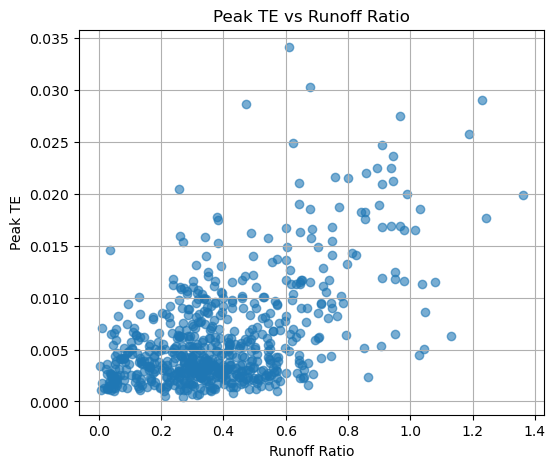

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(
    te_attr_df["runoff_ratio"],
    te_attr_df["peak_TE"],
    alpha=0.6
)

plt.xlabel("Runoff Ratio")
plt.ylabel("Peak TE")
plt.title("Peak TE vs Runoff Ratio")

plt.grid(True)
plt.show()

## Relationship between peak TE and mean precipitation

In this step, I plot peak TE against mean precipitation to examine whether wetter basins tend to have stronger overall information transfer from atmospheric forcing to streamflow.

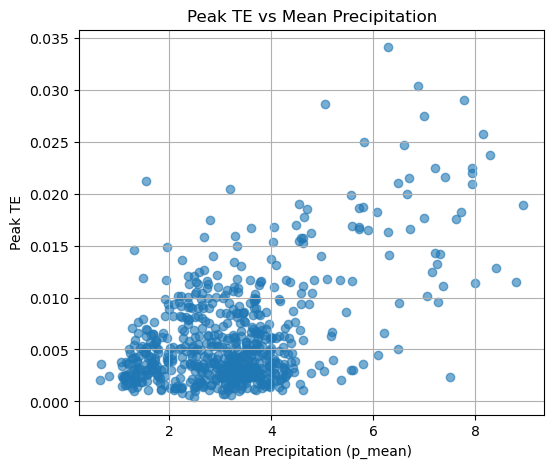

In [19]:
plt.figure(figsize=(6,5))

plt.scatter(
    te_attr_df["p_mean"],
    te_attr_df["peak_TE"],
    alpha=0.6
)

plt.xlabel("Mean Precipitation (p_mean)")
plt.ylabel("Peak TE")
plt.title("Peak TE vs Mean Precipitation")

plt.grid(True)
plt.show()

The plot shows that peak TE generally increases as mean precipitation increases. Wetter basins tend to have stronger information transfer from atmospheric forcing to streamflow, while drier basins usually have weaker TE.

## Relationship between peak TE and aridity

In this step, I plot peak TE against aridity to examine whether drier basins tend to have weaker information transfer from atmospheric forcing to streamflow.

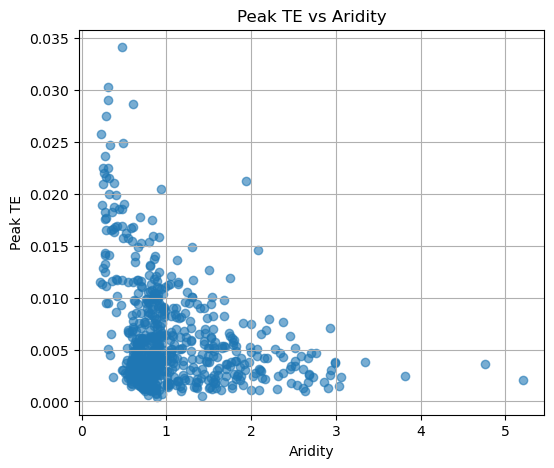

In [20]:
plt.figure(figsize=(6,5))

plt.scatter(
    te_attr_df["aridity"],
    te_attr_df["peak_TE"],
    alpha=0.6
)

plt.xlabel("Aridity")
plt.ylabel("Peak TE")
plt.title("Peak TE vs Aridity")

plt.grid(True)
plt.show()

The plot shows that peak TE decreases as aridity increases. Wetter basins (low aridity) tend to have stronger information transfer to streamflow, while drier basins (high aridity) tend to have weaker TE.

## Relationship between peak TE and basin slope

In this step, I plot peak TE against basin mean slope to examine whether steeper basins tend to have stronger information transfer from forcing to streamflow.

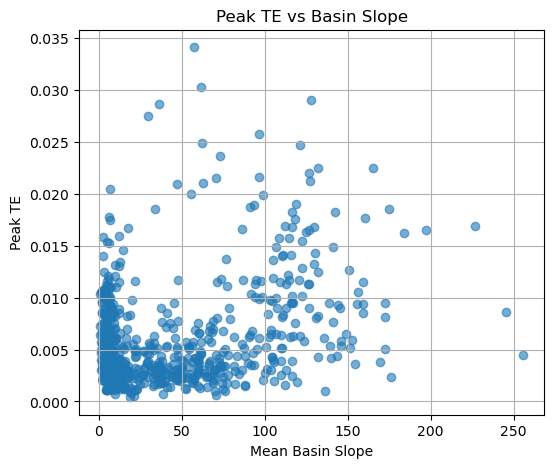

In [21]:
plt.figure(figsize=(6,5))

plt.scatter(
    te_attr_df["slope_mean"],
    te_attr_df["peak_TE"],
    alpha=0.6
)

plt.xlabel("Mean Basin Slope")
plt.ylabel("Peak TE")
plt.title("Peak TE vs Basin Slope")

plt.grid(True)
plt.show()

The plot shows that peak TE tends to increase as basin slope increases, although the relationship is not very strong. Steeper basins generally have faster runoff response, so the information from atmospheric forcing can reach streamflow more quickly and strongly.

## Relationship between peak lag and soil porosity

In this step, I plot peak lag against soil porosity to examine whether basins with higher soil storage tend to have longer response time from forcing to streamflow.

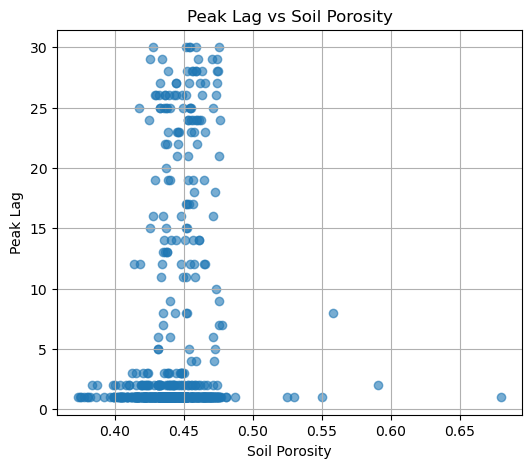

In [22]:
plt.figure(figsize=(6,5))

plt.scatter(
    te_attr_df["soil_porosity"],
    te_attr_df["peak_lag"],
    alpha=0.6
)

plt.xlabel("Soil Porosity")
plt.ylabel("Peak Lag")
plt.title("Peak Lag vs Soil Porosity")

plt.grid(True)
plt.show()

Peak lag has no clear strong relationship with soil porosity. Most basins have short lag, and longer lags appear mainly within the middle porosity range rather than only at the highest porosity values.

## Relationship between peak lag and geologic permeability

In this step, I plot peak lag against geologic permeability to examine whether subsurface flow properties influence the timing of information transfer from forcing to streamflow.

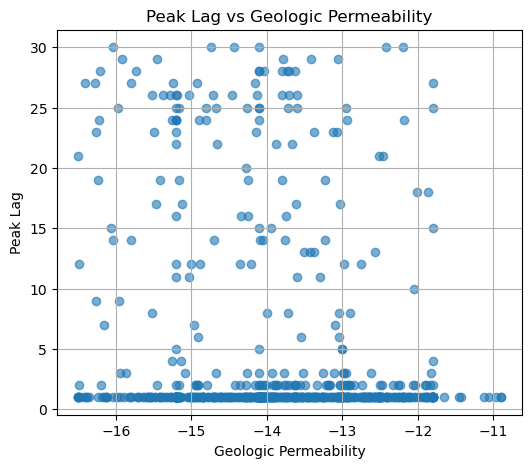

In [23]:
plt.figure(figsize=(6,5))

plt.scatter(
    te_attr_df["geol_permeability"],
    te_attr_df["peak_lag"],
    alpha=0.6
)

plt.xlabel("Geologic Permeability")
plt.ylabel("Peak Lag")
plt.title("Peak Lag vs Geologic Permeability")

plt.grid(True)
plt.show()

The plot shows no clear relationship between geologic permeability and peak lag. Most basins still have short lag (around 1–2 days) regardless of permeability, while a few basins show longer lag. This suggests that geologic permeability alone does not strongly control the timing of TE response across basins.

## Compare basin characteristics between dominant forcing groups

In this step, I compare selected basin characteristics between PRCP-dominated basins and energy-dominated basins (SRAD, Tair, VP) to understand which basin conditions are associated with different dominant forcings.

In [24]:
# Create two groups
te_attr_df["forcing_group"] = te_attr_df["dominant_forcing"].apply(
    lambda x: "PRCP" if x == "PRCP" else "Energy"
)

# Variables to compare
vars_compare = [
    "p_mean",
    "pet_mean",
    "aridity",
    "frac_snow",
    "runoff_ratio",
    "baseflow_index",
    "soil_conductivity",
    "soil_porosity",
    "elev_mean",
    "slope_mean",
    "area_gages2",
    "frac_forest"
]

group_compare = te_attr_df.groupby("forcing_group")[vars_compare].mean().round(3)

print("Mean basin characteristics by forcing group:")
display(group_compare)

Mean basin characteristics by forcing group:


,p_mean,pet_mean,aridity,frac_snow,runoff_ratio,baseflow_index,soil_conductivity,soil_porosity,elev_mean,slope_mean,area_gages2,frac_forest
forcing_group,,,,,,,,,,,,
Energy,2.922,2.719,1.103,0.277,0.402,0.519,1.521,0.444,1110.548,55.346,633.120,0.668
PRCP,3.501,2.837,1.023,0.106,0.376,0.471,1.899,0.441,504.878,39.562,908.244,0.619


Energy-dominated basins are, on average, drier, snowier, higher in elevation, steeper, and have higher baseflow index. PRCP-dominated basins are wetter, larger in area, and have higher soil conductivity. This suggests that precipitation tends to dominate in wetter, more runoff-connected basins, while energy-related forcings dominate more in snow-influenced and high-elevation basins.

## Count basins in the two forcing groups

In this step, I count how many basins are in the PRCP-dominated group and how many are in the energy-dominated group.
This helps show how common each type of basin response is.

In [25]:
forcing_group_counts = te_attr_df["forcing_group"].value_counts()

print("Number of basins by forcing group:")
print(forcing_group_counts)

Number of basins by forcing group:
forcing_group
PRCP      389
Energy    282
Name: count, dtype: int64


More basins are PRCP-dominated than energy-dominated. This means precipitation is the most common dominant forcing across CAMELS basins, but energy-related forcings still dominate in a large number of basins, so both types are important in the basin-to-basin TE analysis.

## Compare median peak TE and peak lag between PRCP and energy groups

In this step, I compare the median peak TE and peak lag between PRCP-dominated and energy-dominated basins.
This helps show how TE strength and timing differ between the two main basin-response groups.

In [26]:
forcing_group_summary = (
    te_attr_df
    .groupby("forcing_group")[["peak_TE", "peak_lag"]]
    .median()
    .round(3)
)

print("Median peak TE and peak lag by forcing group:")
display(forcing_group_summary)

Median peak TE and peak lag by forcing group:


,peak_TE,peak_lag
forcing_group,,
Energy,0.003,3.0
PRCP,0.005,1.0


##  Save main summary tables for basin-to-basin TE analysis

In this step, I save the main summary tables created so far for later interpretation, plotting, and reporting.

In [27]:
# Save dominant forcing group means
group_mean_df.to_csv(OUT_SUMMARY / "mean_camels_attributes_by_dominant_forcing.csv")

# Save peak TE correlations
peak_te_corr.to_csv(OUT_SUMMARY / "correlation_with_peak_TE.csv", header=True)

# Save peak lag correlations
peak_lag_corr.to_csv(OUT_SUMMARY / "correlation_with_peak_lag.csv", header=True)

# Save PRCP vs Energy group means
group_compare.to_csv(OUT_SUMMARY / "mean_camels_attributes_by_forcing_group.csv")

# Save PRCP vs Energy group summary
forcing_group_summary.to_csv(OUT_SUMMARY / "median_peakTE_peaklag_by_forcing_group.csv")

print("Saved summary CSV files to:")
print(OUT_SUMMARY)

Saved summary CSV files to:
C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis\outputs\summary_csv


## Build one compact evidence table for key hydrologic controls

In this step, I summarize the main hydrologic controls in one table using:
(1) correlation with peak TE,
(2) correlation with peak lag, and
(3) mean values in PRCP-dominated and energy-dominated basins.

This helps identify which basin characteristics most clearly explain basin-to-basin TE differences.

In [28]:
# Selected key controls for the main analysis
key_controls = [
    "p_mean",
    "aridity",
    "runoff_ratio",
    "baseflow_index",
    "frac_snow",
    "soil_conductivity",
    "soil_porosity",
    "slope_mean",
    "elev_mean",
    "frac_forest"
]

rows = []

for col in key_controls:
    temp = te_attr_df[["peak_TE", "peak_lag", "forcing_group", col]].dropna().copy()
    
    corr_peak_te = temp["peak_TE"].corr(temp[col])
    corr_peak_lag = temp["peak_lag"].corr(temp[col])
    
    prcp_mean = temp.loc[temp["forcing_group"] == "PRCP", col].mean()
    energy_mean = temp.loc[temp["forcing_group"] == "Energy", col].mean()
    
    rows.append({
        "variable": col,
        "corr_with_peak_TE": corr_peak_te,
        "corr_with_peak_lag": corr_peak_lag,
        "mean_PRCP_group": prcp_mean,
        "mean_Energy_group": energy_mean
    })

evidence_df = pd.DataFrame(rows).round(3)

display(evidence_df)

# save
evidence_df.to_csv(OUT_SUMMARY / "key_hydrologic_controls_evidence_table.csv", index=False)
print("\nSaved:")
print(OUT_SUMMARY / "key_hydrologic_controls_evidence_table.csv")

,variable,corr_with_peak_TE,corr_with_peak_lag,mean_PRCP_group,mean_Energy_group
0,p_mean,0.526,-0.063,3.501,2.922
1,aridity,-0.307,-0.050,1.023,1.103
2,runoff_ratio,0.547,-0.045,0.376,0.402
3,baseflow_index,0.144,-0.015,0.471,0.519
4,frac_snow,0.157,-0.034,0.106,0.277
5,soil_conductivity,0.096,-0.144,1.899,1.521
6,soil_porosity,-0.063,0.150,0.441,0.444
7,slope_mean,0.341,-0.107,39.562,55.346
8,elev_mean,0.072,-0.076,504.878,1110.548
9,frac_forest,0.248,0.041,0.619,0.668



Saved:
C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis\outputs\summary_csv\key_hydrologic_controls_evidence_table.csv


Higher p_mean (0.526), runoff_ratio (0.547), and slope_mean (0.341) are associated with higher peak_TE, while higher aridity (-0.307) is associated with lower peak_TE. Peak lag has weaker relationships, with slightly longer lag for higher soil_porosity (0.150) and shorter lag for higher soil_conductivity (-0.144). Compared with PRCP-dominated basins, Energy-dominated basins have lower p_mean (2.922 vs 3.501), higher frac_snow (0.277 vs 0.106), steeper slope_mean (55.346 vs 39.562), and higher elev_mean (1110.548 vs 504.878).

## Create a reduced table of the main hydrologic controls

In this step, I keep only the most important basin characteristics that best explain basin-to-basin differences in TE magnitude, lag, and dominant forcing.

In [29]:
main_controls = [
    "p_mean",
    "aridity",
    "runoff_ratio",
    "frac_snow",
    "slope_mean",
    "elev_mean",
    "soil_conductivity",
    "baseflow_index"
]

main_evidence_df = evidence_df[evidence_df["variable"].isin(main_controls)].copy()

display(main_evidence_df)

main_evidence_df.to_csv(
    OUT_SUMMARY / "main_hydrologic_controls_reduced_table.csv",
    index=False
)

print("\nSaved:")
print(OUT_SUMMARY / "main_hydrologic_controls_reduced_table.csv")

,variable,corr_with_peak_TE,corr_with_peak_lag,mean_PRCP_group,mean_Energy_group
0,p_mean,0.526,-0.063,3.501,2.922
1,aridity,-0.307,-0.050,1.023,1.103
2,runoff_ratio,0.547,-0.045,0.376,0.402
3,baseflow_index,0.144,-0.015,0.471,0.519
4,frac_snow,0.157,-0.034,0.106,0.277
5,soil_conductivity,0.096,-0.144,1.899,1.521
7,slope_mean,0.341,-0.107,39.562,55.346
8,elev_mean,0.072,-0.076,504.878,1110.548



Saved:
C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis\outputs\summary_csv\main_hydrologic_controls_reduced_table.csv


This reduced table keeps the main basin characteristics that best explain basin-to-basin TE differences. It shows that p_mean, runoff_ratio, and slope_mean are positively related to stronger peak_TE, while aridity is negatively related. It also shows that Energy-dominated basins are generally drier, snowier, steeper, and higher in elevation than PRCP-dominated basins. This makes the main hydrologic controls easier to identify and explain.

## Save the final reduced results table for main hydrologic controls

In this step, I save the reduced table of the main hydrologic controls as the final compact summary for basin-to-basin TE interpretation.

In [30]:
final_main_table_path = OUT_SUMMARY / "final_main_hydrologic_controls_table.csv"
main_evidence_df.to_csv(final_main_table_path, index=False)

print("Saved final main hydrologic controls table:")
print(final_main_table_path)

Saved final main hydrologic controls table:
C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis\outputs\summary_csv\final_main_hydrologic_controls_table.csv


## Build one final summary table why TE varies across basins

In this step, I create one clean summary table of the main findings so that the basin-to-basin TE controls can be discussed clearly.

In [31]:
final_summary_df = main_evidence_df.copy()

final_summary_df["main_message"] = [
    "Higher mean precipitation is linked to stronger peak TE",
    "Higher aridity is linked to weaker peak TE",
    "Higher runoff ratio is linked to stronger peak TE",
    "Energy-dominated basins have slightly higher baseflow influence",
    "Energy-dominated basins are more snow-influenced",
    "Higher soil conductivity is linked to slightly shorter lag",
    "Steeper basins tend to have stronger peak TE",
    "Energy-dominated basins are higher in elevation"
]

display(final_summary_df)

final_summary_path = OUT_SUMMARY / "final_summary_table_whyTEVaries_basinwise.csv"
final_summary_df.to_csv(final_summary_path, index=False)

print("Saved:")
print(final_summary_path)

,variable,corr_with_peak_TE,corr_with_peak_lag,mean_PRCP_group,mean_Energy_group,main_message
0,p_mean,0.526,-0.063,3.501,2.922,Higher mean precipitation is linked to stronge...
1,aridity,-0.307,-0.050,1.023,1.103,Higher aridity is linked to weaker peak TE
2,runoff_ratio,0.547,-0.045,0.376,0.402,Higher runoff ratio is linked to stronger peak TE
3,baseflow_index,0.144,-0.015,0.471,0.519,Energy-dominated basins have slightly higher b...
4,frac_snow,0.157,-0.034,0.106,0.277,Energy-dominated basins are more snow-influenced
5,soil_conductivity,0.096,-0.144,1.899,1.521,Higher soil conductivity is linked to slightly...
7,slope_mean,0.341,-0.107,39.562,55.346,Steeper basins tend to have stronger peak TE
8,elev_mean,0.072,-0.076,504.878,1110.548,Energy-dominated basins are higher in elevation


Saved:
C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis\outputs\summary_csv\final_summary_table_whyTEVaries_basinwise.csv


The table shows that stronger peak_TE is most clearly associated with higher runoff_ratio (0.547), higher p_mean (0.526), and steeper slope_mean (0.341), while higher aridity (-0.307) is associated with weaker peak_TE. It also shows that Energy-dominated basins are more snow-influenced (frac_snow: 0.277 vs 0.106), steeper (55.346 vs 39.562), and higher in elevation (1110.548 vs 504.878) than PRCP-dominated basins. Overall, this supports that basin-to-basin TE differences are mainly linked to wetness, runoff efficiency, snow influence, and topography.

## Save one short research conclusion table

In this step, I create a short conclusion table that keeps only the most important findings for research discussion and reporting.

In [32]:
research_conclusion_df = final_summary_df[
    ["variable", "corr_with_peak_TE", "corr_with_peak_lag", "main_message"]
].copy()

display(research_conclusion_df)

research_conclusion_path = OUT_SUMMARY / "research_conclusion_table.csv"
research_conclusion_df.to_csv(research_conclusion_path, index=False)

print("Saved:")
print(research_conclusion_path)

,variable,corr_with_peak_TE,corr_with_peak_lag,main_message
0,p_mean,0.526,-0.063,Higher mean precipitation is linked to stronge...
1,aridity,-0.307,-0.050,Higher aridity is linked to weaker peak TE
2,runoff_ratio,0.547,-0.045,Higher runoff ratio is linked to stronger peak TE
3,baseflow_index,0.144,-0.015,Energy-dominated basins have slightly higher b...
4,frac_snow,0.157,-0.034,Energy-dominated basins are more snow-influenced
5,soil_conductivity,0.096,-0.144,Higher soil conductivity is linked to slightly...
7,slope_mean,0.341,-0.107,Steeper basins tend to have stronger peak TE
8,elev_mean,0.072,-0.076,Energy-dominated basins are higher in elevation


Saved:
C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis\outputs\summary_csv\research_conclusion_table.csv


This short conclusion table shows the main controls of basin-to-basin TE differences. Stronger peak_TE is mainly linked to higher runoff_ratio (0.547), higher p_mean (0.526), and steeper slope_mean (0.341), while higher aridity (-0.307) is linked to weaker peak_TE. Energy-dominated basins are more snow-influenced and higher in elevation, and soil_conductivity shows a weak link to shorter lag. Overall, wetness, runoff efficiency, snow influence, and topography are the main controls identified so far.